In [187]:
#import filter warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

In [188]:
import pandas_datareader as pdr
import yfinance as yf

In [189]:
from pandas_datareader.famafrench import get_available_datasets
import pandas_datareader.data as web

available_datasets = pd.DataFrame(get_available_datasets())


# Print all available datasets
print(available_datasets)

                                               0
0                      F-F_Research_Data_Factors
1               F-F_Research_Data_Factors_weekly
2                F-F_Research_Data_Factors_daily
3                F-F_Research_Data_5_Factors_2x3
4          F-F_Research_Data_5_Factors_2x3_daily
..                                           ...
292         Emerging_Markets_6_Portfolios_ME_INV
293  Emerging_Markets_6_Portfolios_ME_Prior_12_2
294       Emerging_Markets_4_Portfolios_BE-ME_OP
295         Emerging_Markets_4_Portfolios_OP_INV
296      Emerging_Markets_4_Portfolios_BE-ME_INV

[297 rows x 1 columns]


In [190]:
# Select a dataset, for example 'F-F_Research_Data_Factors'
dataset = 'Asia_Pacific_ex_Japan_5_Factors_Daily'

factors_ = web.DataReader(dataset, 'famafrench')

# Download the selected dataset
factors= pd.DataFrame(factors_[0])/100  # 0 corresponds to 'Monthly' frequency

factors = factors.rename(columns={
    'Mkt-RF': 'Active returns',
    'SMB': 'Size',
    'HML': 'Value',
    'RMW': 'Profitability',
    'CMA': 'Investment'
})




In [191]:
Size = factors.Size
Value = factors.Value
Profitability= factors.Profitability
Investment = factors.Investment

print(factors.head())

            Active returns    Size   Value  Profitability  Investment      RF
Date                                                                         
2019-10-01          0.0009 -0.0040 -0.0028         0.0013     -0.0009  0.0001
2019-10-02         -0.0078  0.0026  0.0069        -0.0073      0.0016  0.0001
2019-10-03         -0.0062  0.0044  0.0004        -0.0045     -0.0022  0.0001
2019-10-04         -0.0013  0.0026 -0.0085         0.0074     -0.0013  0.0001
2019-10-07          0.0010 -0.0017 -0.0018         0.0031     -0.0011  0.0001


In [192]:
data = yf.download(
    ['3010.HK', 'SG9999001903'], 
    start="2019-09-30", 
    interval="1d"
)['Adj Close']


[*********************100%%**********************]  2 of 2 completed


In [193]:
print(data)

              3010.HK  SG9999001903
Date                               
2019-09-30  49.799999        3.4543
2019-10-01        NaN        3.4489
2019-10-02  49.299999        3.4239
2019-10-03  49.299999        3.4198
2019-10-04  49.299999        3.4173
...               ...           ...
2024-09-23  55.880001        3.9503
2024-09-24  57.259998        4.0005
2024-09-25  57.380001        4.0302
2024-09-26  58.880001        4.1142
2024-09-27  59.680000           NaN

[1252 rows x 2 columns]


In [198]:
monthly_returns = data.pct_change().dropna()
print(monthly_returns)

             3010.HK  SG9999001903
Date                              
2019-10-01  0.000000     -0.001563
2019-10-02 -0.010040     -0.007249
2019-10-03  0.000000     -0.001197
2019-10-04  0.000000     -0.000731
2019-10-07  0.000000     -0.000936
...              ...           ...
2024-09-23 -0.000358      0.003863
2024-09-24  0.024696      0.012708
2024-09-25  0.002096      0.007424
2024-09-26  0.026142      0.020843
2024-09-27  0.013587      0.000000

[1251 rows x 2 columns]


In [199]:
bench = monthly_returns['3010.HK']
R = monthly_returns['SG9999001903']
active = R - bench

print(active)

Date
2019-10-01   -0.001563
2019-10-02    0.002791
2019-10-03   -0.001197
2019-10-04   -0.000731
2019-10-07   -0.000936
                ...   
2024-09-23    0.004220
2024-09-24   -0.011988
2024-09-25    0.005328
2024-09-26   -0.005299
2024-09-27   -0.013587
Length: 1251, dtype: float64


In [200]:
df = pd.DataFrame({
    'R': active,
    'F1': Size,
    'F2': Value,
    'F3': Profitability,
    'F4': Investment
}).dropna()

print(df)

Empty DataFrame
Columns: [R, F1, F2, F3, F4]
Index: []


In [158]:
#plot all 

In [159]:
import statsmodels.api as sm
from statsmodels import regression
from statsmodels.regression.rolling import RollingOLS

In [160]:
b1, b2, b3, b4= regression.linear_model.OLS(
    df.R, 
    df[['F1', 'F2', 'F3', 'F4']]
).fit().params

In [161]:
print(f'Sensitivities of active returns to factors:\nSize: {b1}\nValue: {b2} \nProfitability: {b3} \nInvestment: {b4}')

Sensitivities of active returns to factors:
Size: 0.022287002452912968
Value: -0.03588531965519982 
Profitability: 0.17590095066316166 
Investment: -0.0067311524488633395


In [162]:
exog_vars = ["Size", "Value", "Profitability", "Investment"]
print(exog_vars)

['Size', 'Value', 'Profitability', 'Investment']


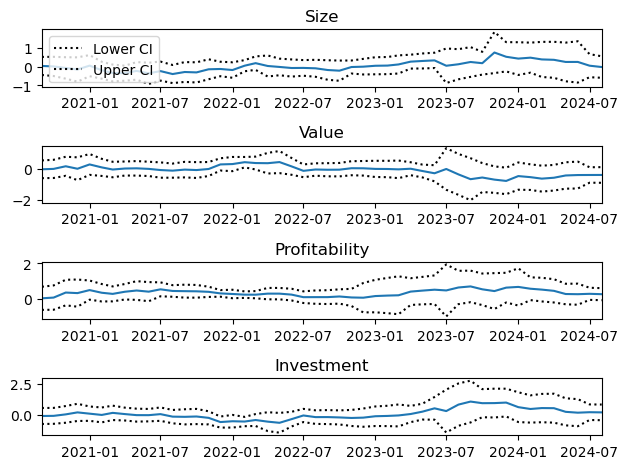

In [163]:

exog = sm.add_constant(factors[exog_vars])
rols = RollingOLS(df.R, exog, window=12)
rres = rols.fit()
fig = rres.plot_recursive_coefficient(variables=exog_vars)

In [164]:
F1 = df.F1
F2 = df.F2
F3 = df.F3
F4 = df.F4

In [165]:
cov = np.cov([F1, F2, F3, F4])
ar_squared = (active.std())**2
mcar1 = (b1 * (b2 * cov[0,1] + b1 * cov[0,0])) / ar_squared
mcar2 = (b2 * (b1 * cov[0,1] + b2 * cov[1,1])) / ar_squared
mcar3 = (b3 * (b4 * cov[0,2] + b3 * cov[2,2])) / ar_squared
mcar4 = (b4 * (b3 * cov[0,3] + b4 * cov[3,3])) / ar_squared
print(f'Size risk contribution: {mcar1}')
print(f'Value risk contribution: {mcar2}')
print(f'Profitability risk contribution: {mcar3}')
print(f'Investment risk contribution: {mcar4}')
print(f'Unexplained risk contribution: {1 - (mcar1 + mcar2 + mcar3 + mcar4)}')

Size risk contribution: 0.0019982329731870713
Value risk contribution: 0.00834853248723058
Profitability risk contribution: 0.08639026849557749
Investment risk contribution: 0.0010438721343830851
Unexplained risk contribution: 0.9022190939096217
